In [ ]:

import pandas as pd
df = pd.read_csv('/content/Dataset-SA.csv')  # Replace with actual filename
df.head()


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


This cell loads the dataset named `Dataset-SA.csv` into a pandas DataFrame and then displays the first 5 rows of the DataFrame to give an initial glimpse of the data structure.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


This cell uses the `df.info()` method to print a concise summary of the DataFrame. This includes the index dtype and column dtypes, non-null values, and memory usage. It's useful for checking data types and identifying missing values.

In [ ]:
df.describe()

,product_name,product_price,Rate,Review,Summary,Sentiment
count,205052,205052,205052,180388,205041,205052
unique,958,525,8,1324,92923,3
top,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,wonderful,good,positive
freq,6005,9150,118765,9016,17430,166581


The `df.describe()` method generates descriptive statistics of the DataFrame. For object (string) columns, it provides count, unique values, top occurring value, and its frequency. This helps in understanding the distribution and characteristics of categorical data.

In [ ]:

!pip install textblob wordcloud seaborn scikit-learn
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

This cell installs necessary libraries like `textblob`, `wordcloud`, `seaborn`, and `scikit-learn`. It then downloads NLTK (Natural Language Toolkit) data packages, which are essential for various text processing tasks such as tokenization, stop words, lemmatization, and part-of-speech tagging.

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return 'a'
    if tag.startswith('V'): return 'v'
    if tag.startswith('N'): return 'n'
    if tag.startswith('R'): return 'r'
    return 'n'

def clean_text(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    pos_tags = pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(t, get_wordnet_pos(tag)) for t, tag in pos_tags]
    return " ".join(lemmas)

df['text_all'] = df['Summary'].fillna('') + ' ' + df['Review'].fillna('')
df['text_clean'] = df['text_all'].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


This cell defines a text cleaning pipeline:

1.  **Imports**: Imports `re` for regular expressions, `stopwords` for common words to remove, `WordNetLemmatizer` for reducing words to their base form, and `pos_tag`, `word_tokenize` for part-of-speech tagging and tokenization.
2.  **NLTK Downloads**: Downloads additional NLTK resources.
3.  **`stop_words`**: Loads English stop words.
4.  **`lemmatizer`**: Initializes the lemmatizer.
5.  **`get_wordnet_pos`**: A helper function to map NLTK's part-of-speech tags to WordNet's tags, crucial for accurate lemmatization.
6.  **`clean_text`**: This function performs the core cleaning:
    *   Handles `NaN` values.
    *   Converts text to lowercase.
    *   Removes URLs and HTML tags.
    *   Removes non-alphabetic characters.
    *   Tokenizes the text (splits into words).
    *   Removes stop words and short words.
    *   Lemmatizes words based on their part-of-speech.
7.  **Feature Engineering**: It combines the `Summary` and `Review` columns into a new column `text_all` and then applies the `clean_text` function to create a `text_clean` column, which is used for further analysis.

In [ ]:

from textblob import TextBlob

def textblob_scores(text):
    sent = TextBlob(text).sentiment
    return pd.Series({'polarity': sent.polarity, 'subjectivity': sent.subjectivity})

scores = df['text_clean'].apply(textblob_scores)
df = pd.concat([df, scores], axis=1)

def polarity_to_class(p):
    if p > 0.05: return 'positive'
    if p < -0.05: return 'negative'
    return 'neutral'

df['tb_class'] = df['polarity'].apply(polarity_to_class)


This cell uses the `TextBlob` library for sentiment analysis:

1.  **`textblob_scores` function**: Takes cleaned text and returns its polarity (a float within [-1.0, 1.0], where 1.0 is positive sentiment and -1.0 is negative sentiment) and subjectivity (a float within [0.0, 1.0], where 0.0 is objective and 1.0 is subjective).
2.  **Applying `textblob_scores`**: Applies this function to the `text_clean` column and concatenates the resulting polarity and subjectivity scores to the main DataFrame.
3.  **`polarity_to_class` function**: Categorizes the numerical `polarity` score into 'positive', 'negative', or 'neutral' based on thresholds.
4.  **`tb_class` column**: Creates a new column `tb_class` containing the TextBlob-derived sentiment categories.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Drop rows where 'Sentiment' is NaN before splitting the data
df_cleaned = df.dropna(subset=['Sentiment'])

X_train, X_test, y_train, y_test = train_test_split(
    df_cleaned['text_clean'], df_cleaned['Sentiment'], test_size=0.2, random_state=42, stratify=df_cleaned['Sentiment']
)

tfidf = TfidfVectorizer(min_df=3, ngram_range=(1,2))
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr, y_train)
pred = clf.predict(Xte)

print(classification_report(y_test, pred))

df['predicted_sentiment'] = clf.predict(tfidf.transform(df['text_clean']))

              precision    recall  f1-score   support

    negative       0.85      0.83      0.84      5646
     neutral       0.71      0.26      0.38      2048
    positive       0.94      0.98      0.96     33317

    accuracy                           0.93     41011
   macro avg       0.83      0.69      0.73     41011
weighted avg       0.92      0.93      0.92     41011



This cell sets up and trains a machine learning model for sentiment classification:

1.  **Imports**: Imports `train_test_split` for splitting data, `TfidfVectorizer` for text feature extraction, `LogisticRegression` for the classification model, and `classification_report` for evaluating the model.
2.  **Data Preparation**: Drops rows with missing values in the 'Sentiment' column to ensure clean data for training.
3.  **Train-Test Split**: Splits the cleaned text (`text_clean`) and the target `Sentiment` column into training and testing sets. `stratify` ensures that the proportion of sentiment classes is maintained in both sets.
4.  **TF-IDF Vectorization**: Initializes `TfidfVectorizer` to convert text data into numerical TF-IDF (Term Frequency-Inverse Document Frequency) features. `min_df=3` ignores terms that appear in less than 3 documents, and `ngram_range=(1,2)` considers single words and pairs of words.
    *   `fit_transform` learns the vocabulary and transforms the training data.
    *   `transform` applies the learned vocabulary to the test data.
5.  **Model Training**: Initializes and trains a `LogisticRegression` model on the TF-IDF transformed training data.
6.  **Prediction and Evaluation**: Uses the trained model to predict sentiments on the test set and prints a `classification_report`, which shows precision, recall, f1-score, and support for each sentiment class.
7.  **Full Data Prediction**: Finally, it predicts the sentiment for the entire `text_clean` column in the original DataFrame and stores it in a new `predicted_sentiment` column.

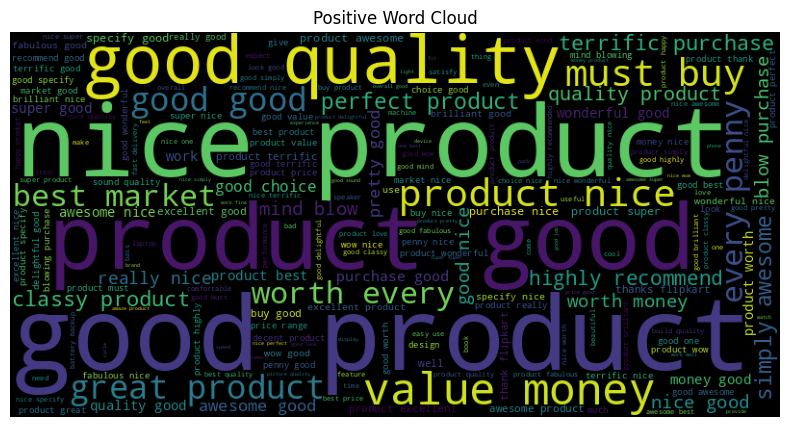

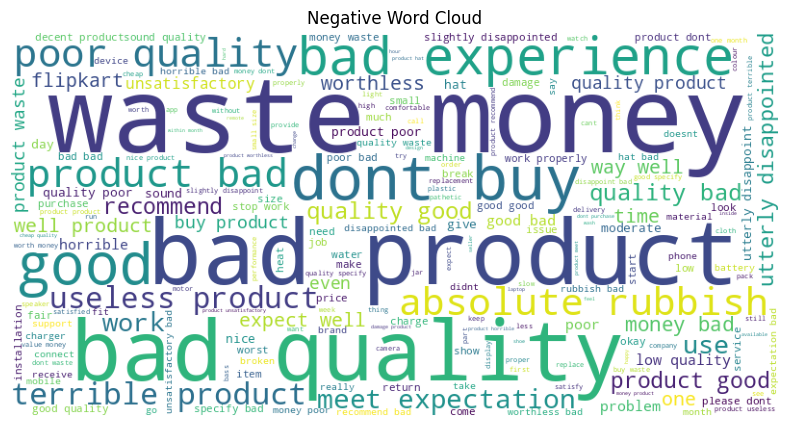

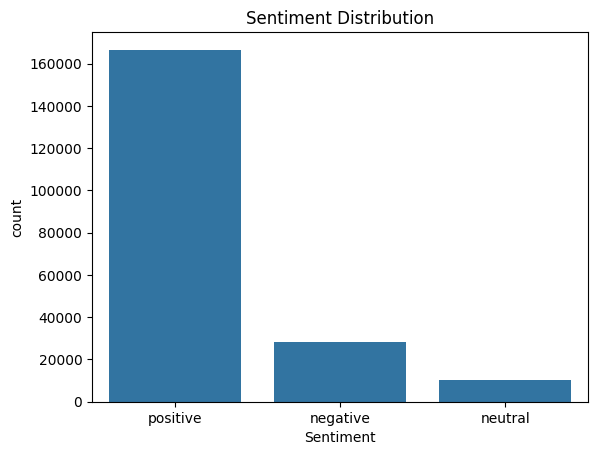

In [ ]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

pos_text = " ".join(df[df['Sentiment']=='positive']['text_clean'])
neg_text = " ".join(df[df['Sentiment']=='negative']['text_clean'])

wc_pos = WordCloud(width=800, height=400, background_color='black').generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color='white').generate(neg_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos); plt.axis('off'); plt.title('Positive Word Cloud')
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(wc_neg); plt.axis('off'); plt.title('Negative Word Cloud')
plt.show()

sns.countplot(x='Sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()


This cell performs exploratory data analysis through visualizations:

1.  **Imports**: Imports `WordCloud` for generating word clouds, `matplotlib.pyplot` for plotting, and `seaborn` for enhanced statistical visualizations.
2.  **Word Cloud Data Preparation**: Concatenates all cleaned positive sentiment texts into `pos_text` and all cleaned negative sentiment texts into `neg_text`.
3.  **Positive Word Cloud**: Generates and displays a word cloud for positive sentiment words, showing frequently occurring words in larger fonts.
4.  **Negative Word Cloud**: Generates and displays a word cloud for negative sentiment words.
5.  **Sentiment Distribution Plot**: Uses `seaborn.countplot` to visualize the distribution of sentiments in the DataFrame, showing the count of each sentiment category ('positive', 'negative', 'neutral').

In [ ]:

df.to_csv('flipkart_processed.csv', index=False)
from google.colab import files
files.download('flipkart_processed.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This cell saves the processed DataFrame and allows for downloading it:

1.  **Save to CSV**: The DataFrame `df`, which now includes cleaned text, TextBlob scores, and predicted sentiments, is saved to a new CSV file named `flipkart_processed.csv`. `index=False` prevents pandas from writing the DataFrame index as a column in the CSV.
2.  **Download File**: `files.download('flipkart_processed.csv')` triggers a download of the newly created CSV file to the user's local machine, which is a common utility in Google Colab for retrieving generated files.